<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Stochastic-Simulations/blob/master/Epidemia_2_15__2_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 1 (Exercise 2.15)
---


*   Solve $\frac{dI(t)}{dt}
= (α − β)I(t).$ with initial condition $I(0) = 1$.

It's a trivial differential equation:

$$
I(t) = Ce^{(\alpha-\beta)t}
$$

$$
I(0) = 1 ⇒ C = 1 ⇒ I(t) = e^{(\alpha-\beta)t}
$$





In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def gillespie_sampler(alpha, beta, I0, T_max):
    """
    Simulates Markov process for epidemic.
    """
    t = [0.0]
    I = [I0]

    while t[-1] < T_max and I[-1] > 0:
        current_I = I[-1]

        # updating intensivities
        rate_up = alpha * current_I
        rate_down = beta * current_I

        total_rate = rate_up + rate_down

        if total_rate == 0:
            break

        # sampling moments of events
        dt = np.random.exponential(1.0 / total_rate)
        t.append(t[-1] + dt)

        # sampling type of event (new ill or healthy)
        if np.random.rand() < rate_up / total_rate:
            I.append(current_I + 1) # one new ill person
        else:
            I.append(current_I - 1) # one new healthy person

    return np.array(t), np.array(I)

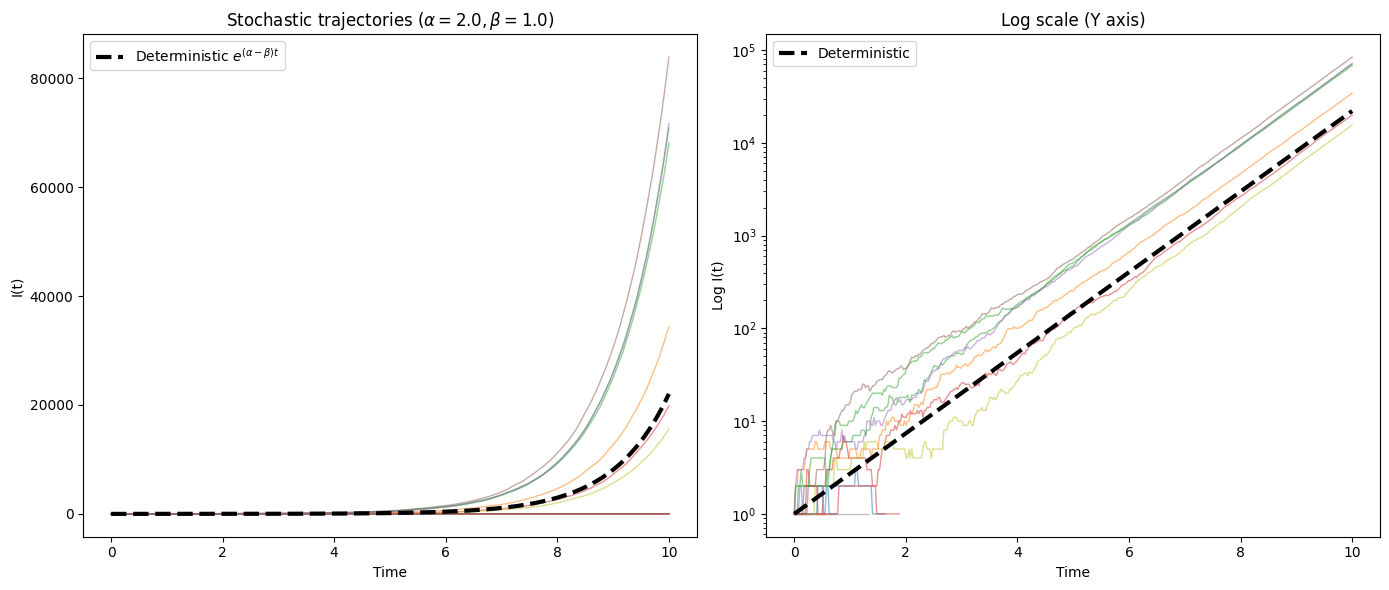

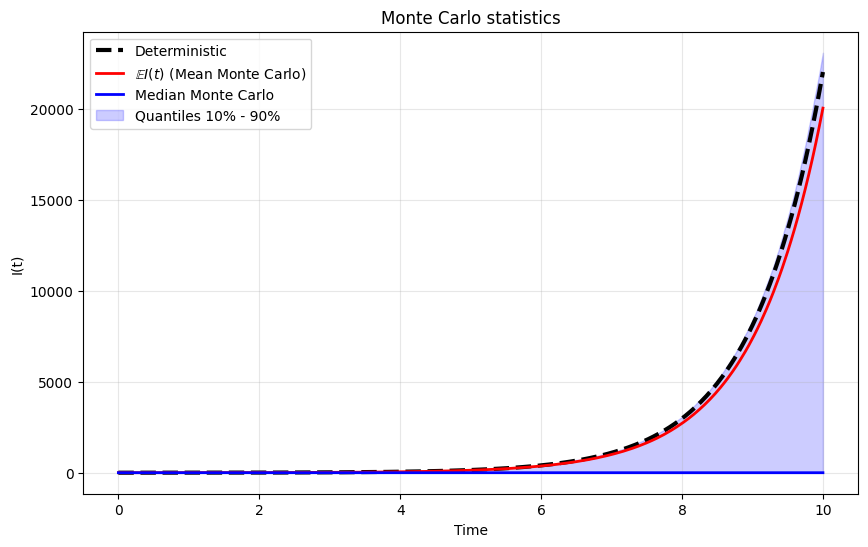

In [ ]:
alpha = 2.0
beta = 1.0
I0 = 1
T_max = 10.0
num_simulations = 500

# time vector
time_grid = np.linspace(0, T_max, 400)
I_interpolated = np.zeros((num_simulations, len(time_grid)))

# Section 1: Generating trajectories and interpolation for common time grid
for i in range(num_simulations):
    t_sim, I_sim = gillespie_sampler(alpha, beta, I0, T_max)

    indices = np.searchsorted(t_sim, time_grid, side='right') - 1
    I_interpolated[i, :] = I_sim[indices]

# deterministic I
I_deterministic = I0 * np.exp((alpha - beta) * time_grid)

# Section 2: Plotting with a few trajectories
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for i in range(15): # Plot 15 trajectories
    ax1.plot(time_grid, I_interpolated[i], alpha=0.5, linewidth=1)
    I_log = np.where(I_interpolated[i] > 0, I_interpolated[i], np.nan)
    ax2.plot(time_grid, I_log, alpha=0.5, linewidth=1)

ax1.plot(time_grid, I_deterministic, 'k--', linewidth=3, label='Deterministic $e^{(\\alpha-\\beta)t}$')
ax1.set_title(f'Stochastic trajectories ($\\alpha={alpha}, \\beta={beta}$)')
ax1.set_xlabel('Time')
ax1.set_ylabel('I(t)')
ax1.legend()

ax2.plot(time_grid, I_deterministic, 'k--', linewidth=3, label='Deterministic')
ax2.set_title('Log scale (Y axis)')
ax2.set_yscale('log')
ax2.set_xlabel('Time')
ax2.set_ylabel('Log I(t)')
ax2.legend()

plt.tight_layout()
plt.show()

# Section 3: Plotting for Monte Carlo method - mean, median, quantiles
mean_I = np.mean(I_interpolated, axis=0)
median_I = np.median(I_interpolated, axis=0)
q10 = np.percentile(I_interpolated, 30, axis=0)
q90 = np.percentile(I_interpolated, 70, axis=0)

plt.figure(figsize=(10, 6))
plt.plot(time_grid, I_deterministic, 'k--', linewidth=3, label='Deterministic')
plt.plot(time_grid, mean_I, 'r-', linewidth=2, label='$\\mathbb{E}I(t)$ (Mean Monte Carlo)')
plt.plot(time_grid, median_I, 'b-', linewidth=2, label='Median Monte Carlo')
plt.fill_between(time_grid, q10, q90, color='blue', alpha=0.2, label='Quantiles 10% - 90%')

plt.title('Monte Carlo statistics')
plt.xlabel('Time')
plt.ylabel('I(t)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Task 2 (Exercise 2.16)
---

In [ ]:
def gillespie_sir(alpha, beta, l):
    """
    Simulates SIR with Gillespie algorithm.
    """
    current_t = 0.0
    current_S = l - 1
    current_I = 1
    current_R = 0

    # storage lists for results
    t_vals = [current_t]
    S_vals = [current_S]
    I_vals = [current_I]
    R_vals = [current_R]

    # simulation runs while number of ill is non-zero
    while current_I > 0:
        # updating intensitivies
        rate_inf = alpha * (current_S / l) * current_I
        rate_rec = beta * current_I
        total_rate = rate_inf + rate_rec

        if total_rate == 0:
            break

        # sampling moments of events
        dt = np.random.exponential(1.0 / total_rate)
        current_t += dt

        # sampling type of event
        if np.random.rand() < (rate_inf / total_rate):
            current_S -= 1
            current_I += 1
        else:
            current_I -= 1
            current_R += 1

        t_vals.append(current_t)
        S_vals.append(current_S)
        I_vals.append(current_I)
        R_vals.append(current_R)

    return np.array(t_vals), np.array(S_vals), np.array(I_vals), np.array(R_vals)

Simulation 1: Peak = 229 ill | Time of peak = 4.31 | Total infections (R_final) = 847 (84.7%)
Simulation 2: Peak = 159 ill | Time of peak = 8.73 | Total infections (R_final) = 808 (80.8%)
Simulation 4: Peak = 181 ill | Time of peak = 7.80 | Total infections (R_final) = 803 (80.3%)
Simulation 8: Peak = 199 ill | Time of peak = 4.93 | Total infections (R_final) = 799 (79.9%)
Simulation 9: Peak = 128 ill | Time of peak = 6.28 | Total infections (R_final) = 779 (77.9%)
Simulation 10: Peak = 152 ill | Time of peak = 7.30 | Total infections (R_final) = 772 (77.2%)
Simulation 11: Peak = 159 ill | Time of peak = 8.10 | Total infections (R_final) = 773 (77.3%)
Simulation 12: Peak = 152 ill | Time of peak = 10.39 | Total infections (R_final) = 766 (76.6%)
Simulation 14: Peak = 182 ill | Time of peak = 5.54 | Total infections (R_final) = 778 (77.8%)
Simulation 16: Peak = 117 ill | Time of peak = 7.53 | Total infections (R_final) = 777 (77.7%)
Simulation 18: Peak = 182 ill | Time of peak = 5.94 | 

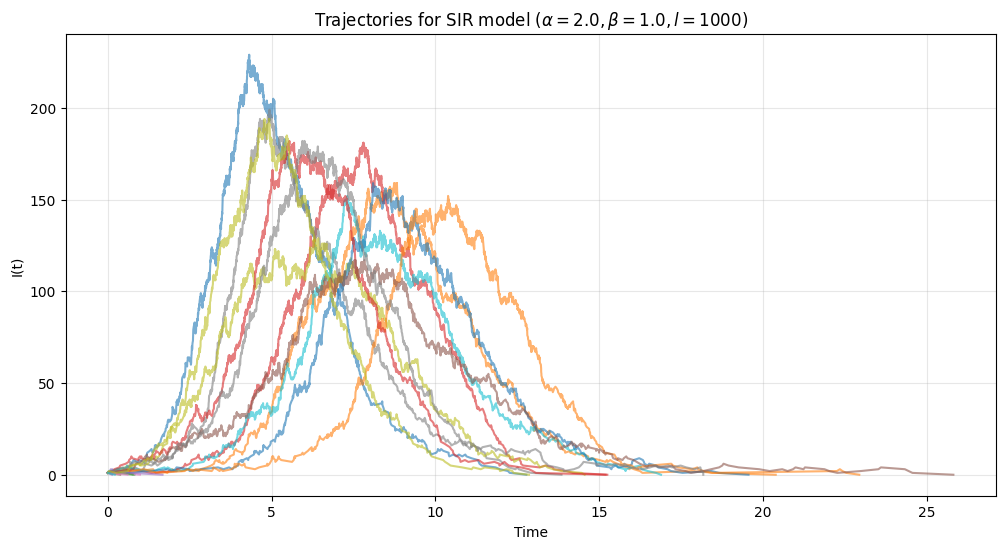

In [ ]:
alpha = 2.0
beta = 1.0
l = 1000
num_simulations = 20

plt.figure(figsize=(12, 6))


epidemics_count = 0

for i in range(num_simulations):
    t, S, I, R = gillespie_sir(alpha, beta, l)

    plt.plot(t, I, alpha=0.6, linewidth=1.5)

    # Gathering statistics only for cases when epidemic developed
    # We assume that epidemic developed if over 5% of population was ill at any point
    max_I = np.max(I)
    if max_I > l * 0.05:
        epidemics_count += 1
        t_peak = t[np.argmax(I)]
        R_final = R[-1]
        print(f"Simulation {i+1}: Peak = {max_I} ill | Time of peak = {t_peak:.2f} | Total infections (R_final) = {R_final} ({R_final/l*100:.1f}%)")

print(f"\nOut of {num_simulations} simulations, epidemic developed in {epidemics_count} cases.")

plt.title(f'Trajectories for SIR model ($\\alpha={alpha}, \\beta={beta}, l={l}$)')
plt.xlabel('Time')
plt.ylabel('I(t)')
plt.grid(True, alpha=0.3)
plt.show()